In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import os

In [3]:
all_route = pd.read_csv("80mRoute.csv")
all_route

,Unnamed: 0,ele,lat,lon,distance,temp
0,0,38.688,-12.466018,130.842784,0.000000e+00,0.0
1,10,40.116,-12.465523,130.842627,8.069656e+01,1.0
2,16,39.141,-12.464773,130.843397,1.991709e+02,2.0
3,18,37.385,-12.464375,130.843787,2.604598e+02,3.0
4,22,36.143,-12.463871,130.844295,3.391211e+02,4.0
...,...,...,...,...,...,...
22128,38118,58.375,-34.927461,138.622595,3.037944e+06,37974.0
22129,38195,58.289,-34.927710,138.622494,3.038001e+06,37975.0
22130,38201,59.254,-34.927642,138.621605,3.038084e+06,37976.0
22131,38207,57.991,-34.927589,138.620574,3.038179e+06,37977.0


In [4]:
max_d = 0
tmp = 0

for row in all_route.index:
    if row == 0:
        continue
    
    if max_d < all_route.loc[row, 'distance'] - all_route.loc[row-1, 'distance']:
        max_d = all_route.loc[row, 'distance'] - all_route.loc[row-1, 'distance']
        shipsheki = row
    
    if all_route.loc[row, 'distance'] - all_route.loc[row-1, 'distance'] > 80:
        tmp += 1
    
print(max_d, shipsheki, tmp)

3633.059875387 9011 14818


In [5]:
all_route

,Unnamed: 0,ele,lat,lon,distance,temp
0,0,38.688,-12.466018,130.842784,0.000000e+00,0.0
1,10,40.116,-12.465523,130.842627,8.069656e+01,1.0
2,16,39.141,-12.464773,130.843397,1.991709e+02,2.0
3,18,37.385,-12.464375,130.843787,2.604598e+02,3.0
4,22,36.143,-12.463871,130.844295,3.391211e+02,4.0
...,...,...,...,...,...,...
22128,38118,58.375,-34.927461,138.622595,3.037944e+06,37974.0
22129,38195,58.289,-34.927710,138.622494,3.038001e+06,37975.0
22130,38201,59.254,-34.927642,138.621605,3.038084e+06,37976.0
22131,38207,57.991,-34.927589,138.620574,3.038179e+06,37977.0


In [6]:
diff = all_route['temp'].diff()
diff

0        NaN
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
22128    1.0
22129    1.0
22130    1.0
22131    1.0
22132    2.0
Name: temp, Length: 22133, dtype: float64

In [7]:
A = pd.DataFrame([[1, 2], [3, 4]])
B = pd.DataFrame([[5, 6], [7, 8]])

C = pd.concat([A, B]).reset_index(drop=True)
C

,0,1
0,1,2
1,3,4
2,5,6
3,7,8


In [10]:
rows = []

for idx in all_route.index:
    if idx == 0:
        rows.append(all_route.loc[idx].copy())
        continue

    n = diff.loc[idx]

    if pd.isna(n):
        continue

    n = int(n)

    # idx-1 지점부터 idx 지점 사이를 n등분해서 중간점 추가
    if n > 1:
        for i in range(1, n):
            row = all_route.loc[idx-1].copy()

            row['ele'] = round(all_route.loc[idx-1, 'ele'] + (
                all_route.loc[idx, 'ele'] - all_route.loc[idx-1, 'ele']
            ) * i / n, 7)

            row['lat'] = round(all_route.loc[idx-1, 'lat'] + (
                all_route.loc[idx, 'lat'] - all_route.loc[idx-1, 'lat']
            ) * i / n, 7)

            row['lon'] = round(all_route.loc[idx-1, 'lon'] + (
                all_route.loc[idx, 'lon'] - all_route.loc[idx-1, 'lon']
            ) * i / n, 7)

            row['distance'] = round(all_route.loc[idx-1, 'distance'] + (
                all_route.loc[idx, 'distance'] - all_route.loc[idx-1, 'distance']
            ) * i / n, 7)

            row['temp'] = all_route.loc[idx-1, 'temp'] + i

            rows.append(row)

    # 마지막에 원래 idx 행 추가
    rows.append(all_route.loc[idx].copy())

Route = pd.DataFrame(rows).reset_index(drop=True)
Route

,Unnamed: 0,ele,lat,lon,distance,temp
0,0.0,38.688,-12.466018,130.842784,0.000000e+00,0.0
1,10.0,40.116,-12.465523,130.842627,8.069656e+01,1.0
2,16.0,39.141,-12.464773,130.843397,1.991709e+02,2.0
3,18.0,37.385,-12.464375,130.843787,2.604598e+02,3.0
4,22.0,36.143,-12.463871,130.844295,3.391211e+02,4.0
...,...,...,...,...,...,...
37975,38195.0,58.289,-34.927710,138.622494,3.038001e+06,37975.0
37976,38201.0,59.254,-34.927642,138.621605,3.038084e+06,37976.0
37977,38207.0,57.991,-34.927589,138.620574,3.038179e+06,37977.0
37978,38207.0,56.911,-34.927626,138.619792,3.038250e+06,37978.0


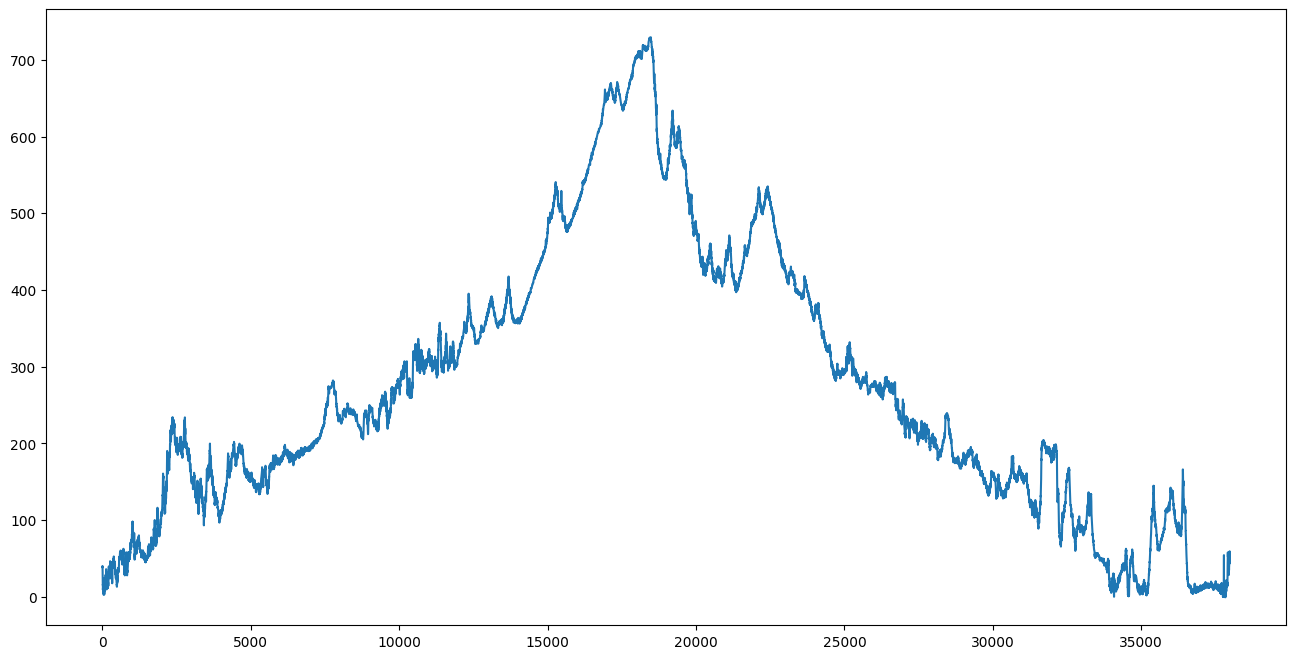

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.plot(Route.index, Route['ele'])